In [75]:
import requests
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


In [76]:
adm4_list = [

"73.01.01.1001",
"73.01.01.1002",
"73.01.01.1003",

"73.01.02.1001",
"73.01.02.1002",
"73.01.02.2003",
"73.01.02.2004",
"73.01.02.2005",
"73.01.02.2006",
"73.01.02.2007",
"73.01.02.2008",

"73.01.03.1001",
"73.01.03.1002",
"73.01.03.2003",
"73.01.03.2004",
"73.01.03.2005",
"73.01.03.2006",
"73.01.03.2007",
"73.01.03.2008",
"73.01.03.2009",
"73.01.03.2010",
"73.01.03.2011",

"73.01.04.2001",
"73.01.04.2002",
"73.01.04.2003",
"73.01.04.2004",
"73.01.04.2005",
"73.01.04.2006",
"73.01.04.2008",
"73.01.04.2010",

"73.01.05.2001",
"73.01.05.2002",
"73.01.05.2003",
"73.01.05.2004",
"73.01.05.2005",
"73.01.05.2006",
"73.01.05.2007",
"73.01.05.2008",
"73.01.05.2009",
"73.01.05.2010",
"73.01.05.2011",
"73.01.05.2012",

"73.01.06.2001",
"73.01.06.2003",
"73.01.06.2005",
"73.01.06.2006",
"73.01.06.2007",

"73.01.07.2001",
"73.01.07.2002",
"73.01.07.2003",
"73.01.07.2004",
"73.01.07.2005",
"73.01.07.2006",
"73.01.07.2007",
"73.01.07.2008",

"73.01.08.2001",
"73.01.08.2002",
"73.01.08.2003",
"73.01.08.2004",
"73.01.08.2005",
"73.01.08.2006",
"73.01.08.2007",
"73.01.08.2008",
"73.01.08.2009",

"73.01.09.2001",
"73.01.09.2002",
"73.01.09.2003",
"73.01.09.2004",
"73.01.09.2005",
"73.01.09.2006",

"73.01.10.2001"

]

print("Jumlah ADM4 :", len(adm4_list))

Jumlah ADM4 : 71


In [77]:
def ambil_data_bmkg(adm4):

    url = f"https://api.bmkg.go.id/publik/prakiraan-cuaca?adm4={adm4}"

    try:

        response = requests.get(url, timeout=10)

        if response.status_code == 200:

            return response.json()

        else:

            return None

    except:

        return None

In [78]:
def parsing_data(data, adm4):

    records = []

    if not data:

        return records

    if isinstance(data, list):

        data = {"data": data}

    for wilayah in data["data"]:

        for prakiraan in wilayah["cuaca"]:

            for item in prakiraan:

                records.append({

                    "Waktu": item["local_datetime"],

                    "Suhu": item["t"],

                    "Kelembaban": item["hu"],

                    "Cuaca": item["weather_desc"],

                    "Angin": item["ws"],

                    "Visibilitas": item.get("vs",0),

                    "Tutupan_Awan": item.get("tcc",0),

                    "Curah_Hujan": item.get("tp",0),

                    "Arah_Angin": item.get("wd","N"),

                    "ADM4": adm4

                })

    return records

In [79]:
print("="*60)
print("MENGAMBIL DATA REALTIME BMKG")
print("="*60)

seluruh_data = []

berhasil = 0

gagal = 0

for adm in adm4_list:

    data = ambil_data_bmkg(adm)

    if data:

        hasil = parsing_data(data, adm)

        seluruh_data.extend(hasil)

        berhasil += 1

        print(f"✓ {adm} ({len(hasil)} data)")

    else:

        gagal += 1

        print(f"✗ {adm}")

print()

print("="*60)

print("ADM4 Berhasil :", berhasil)

print("ADM4 Gagal :", gagal)

print("="*60)

MENGAMBIL DATA REALTIME BMKG
✓ 73.01.01.1001 (19 data)
✓ 73.01.01.1002 (19 data)
✓ 73.01.01.1003 (19 data)
✓ 73.01.02.1001 (19 data)
✓ 73.01.02.1002 (17 data)
✓ 73.01.02.2003 (19 data)
✓ 73.01.02.2004 (19 data)
✓ 73.01.02.2005 (19 data)
✓ 73.01.02.2006 (19 data)
✓ 73.01.02.2007 (19 data)
✓ 73.01.02.2008 (19 data)
✓ 73.01.03.1001 (19 data)
✓ 73.01.03.1002 (19 data)
✓ 73.01.03.2003 (19 data)
✓ 73.01.03.2004 (19 data)
✓ 73.01.03.2005 (19 data)
✓ 73.01.03.2006 (19 data)
✓ 73.01.03.2007 (19 data)
✓ 73.01.03.2008 (19 data)
✓ 73.01.03.2009 (19 data)
✓ 73.01.03.2010 (19 data)
✓ 73.01.03.2011 (19 data)
✓ 73.01.04.2001 (19 data)
✓ 73.01.04.2002 (19 data)
✓ 73.01.04.2003 (19 data)
✓ 73.01.04.2004 (19 data)
✓ 73.01.04.2005 (19 data)
✓ 73.01.04.2006 (19 data)
✓ 73.01.04.2008 (17 data)
✓ 73.01.04.2010 (19 data)
✓ 73.01.05.2001 (19 data)
✓ 73.01.05.2002 (19 data)
✓ 73.01.05.2003 (19 data)
✓ 73.01.05.2004 (19 data)
✓ 73.01.05.2005 (17 data)
✓ 73.01.05.2006 (19 data)
✓ 73.01.05.2007 (19 data)
✓ 73.01.0

In [80]:
df = pd.DataFrame(seluruh_data)

df["Waktu"] = pd.to_datetime(df["Waktu"])

df = df.sort_values("Waktu")

df.reset_index(drop=True, inplace=True)

print("Jumlah Data :", len(df))

display(df.head())

Jumlah Data : 1305


,Waktu,Suhu,Kelembaban,Cuaca,Angin,Visibilitas,Tutupan_Awan,Curah_Hujan,Arah_Angin,ADM4
0,2026-06-30 23:00:00,25,80,Cerah Berawan,8.0,7987,90,0.0,E,73.01.04.2008
1,2026-06-30 23:00:00,26,76,Cerah Berawan,12.8,7987,90,0.0,E,73.01.05.2005
2,2026-06-30 23:00:00,25,79,Cerah Berawan,11.0,7987,85,0.0,E,73.01.02.1002
3,2026-07-01 00:00:00,27,74,Berawan,9.9,7988,92,0.0,E,73.01.09.2001
4,2026-07-01 00:00:00,26,78,Cerah Berawan,11.2,7988,90,0.0,E,73.01.03.2008


In [81]:

print("="*60)
print("INFORMASI DATASET")
print("="*60)

print(df.info())

print()

print("Ukuran Dataset :", df.shape)

print()

print("Nama Kolom")

print(df.columns.tolist())

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1305 entries, 0 to 1304
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Waktu         1305 non-null   datetime64[ns]
 1   Suhu          1305 non-null   int64         
 2   Kelembaban    1305 non-null   int64         
 3   Cuaca         1305 non-null   object        
 4   Angin         1305 non-null   float64       
 5   Visibilitas   1305 non-null   int64         
 6   Tutupan_Awan  1305 non-null   int64         
 7   Curah_Hujan   1305 non-null   float64       
 8   Arah_Angin    1305 non-null   object        
 9   ADM4          1305 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 102.1+ KB
None

Ukuran Dataset : (1305, 10)

Nama Kolom
['Waktu', 'Suhu', 'Kelembaban', 'Cuaca', 'Angin', 'Visibilitas', 'Tutupan_Awan', 'Curah_Hujan', 'Arah_Angin', 'ADM4']


In [84]:
print("="*60)
print("DATASET HASIL PENGAMBILAN API BMKG")
print("="*60)

display(df.head(10))

DATASET HASIL PENGAMBILAN API BMKG


,Waktu,Suhu,Kelembaban,Cuaca,Angin,Visibilitas,Tutupan_Awan,Curah_Hujan,Arah_Angin,ADM4
0,2026-06-30 23:00:00,25,80,Cerah Berawan,8.0,7987,90,0.0,E,73.01.04.2008
1,2026-06-30 23:00:00,26,76,Cerah Berawan,12.8,7987,90,0.0,E,73.01.05.2005
2,2026-06-30 23:00:00,25,79,Cerah Berawan,11.0,7987,85,0.0,E,73.01.02.1002
3,2026-07-01 00:00:00,27,74,Berawan,9.9,7988,92,0.0,E,73.01.09.2001
4,2026-07-01 00:00:00,26,78,Cerah Berawan,11.2,7988,90,0.0,E,73.01.03.2008
5,2026-07-01 00:00:00,27,74,Berawan,10.6,7988,95,0.0,E,73.01.07.2007
6,2026-07-01 00:00:00,26,77,Cerah Berawan,11.2,7988,89,0.0,E,73.01.03.2007
7,2026-07-01 00:00:00,27,76,Berawan,9.2,7988,95,0.0,E,73.01.07.2008
8,2026-07-01 00:00:00,26,78,Berawan,11.2,7988,90,0.0,E,73.01.03.2006
9,2026-07-01 00:00:00,27,75,Cerah Berawan,12.6,7988,90,0.0,E,73.01.08.2001


In [85]:
print("="*60)
print("STATISTIK DESKRIPTIF")
print("="*60)

display(df.describe())

STATISTIK DESKRIPTIF


,Waktu,Suhu,Kelembaban,Angin,Visibilitas,Tutupan_Awan,Curah_Hujan
count,1305,1305.000000,1305.000000,1305.000000,1305.000000,1305.000000,1305.000000
mean,2026-07-02 02:50:37.241379328,26.902682,75.726437,15.477165,12911.210728,48.327969,0.016245
min,2026-06-30 23:00:00,24.000000,61.000000,6.300000,7984.000000,0.000000,0.000000
25%,2026-07-01 12:00:00,26.000000,73.000000,13.200000,7989.000000,15.000000,0.000000
50%,2026-07-02 03:00:00,27.000000,76.000000,15.500000,7996.000000,43.000000,0.000000
75%,2026-07-02 18:00:00,28.000000,79.000000,17.600000,14223.000000,86.000000,0.000000
max,2026-07-03 06:00:00,29.000000,89.000000,25.600000,35140.000000,100.000000,0.400000
std,NaN,0.914539,4.638408,3.265111,9020.388255,34.429260,0.047285


In [86]:
print("="*60)
print("MISSING VALUE")
print("="*60)

missing = df.isnull().sum()

display(missing)

print()

print("Total Missing Value :", missing.sum())

MISSING VALUE


Waktu           0
Suhu            0
Kelembaban      0
Cuaca           0
Angin           0
Visibilitas     0
Tutupan_Awan    0
Curah_Hujan     0
Arah_Angin      0
ADM4            0
dtype: int64


Total Missing Value : 0


In [87]:
print("="*60)
print("DATA DUPLIKAT")
print("="*60)

duplicate = df.duplicated().sum()

print("Jumlah Data Duplikat :", duplicate)

DATA DUPLIKAT
Jumlah Data Duplikat : 0


In [88]:
print("="*60)
print("DATA CLEANING")
print("="*60)

# Menghapus data duplikat
df.drop_duplicates(inplace=True)

# Menghapus missing value
df.dropna(inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

print("Jumlah Data Setelah Cleaning :", len(df))

DATA CLEANING
Jumlah Data Setelah Cleaning : 1305


In [89]:
print("="*60)
print("DISTRIBUSI KONDISI CUACA")
print("="*60)

print(df["Cuaca"].value_counts())

DISTRIBUSI KONDISI CUACA
Cuaca
Cerah            773
Cerah Berawan    326
Berawan          206
Name: count, dtype: int64


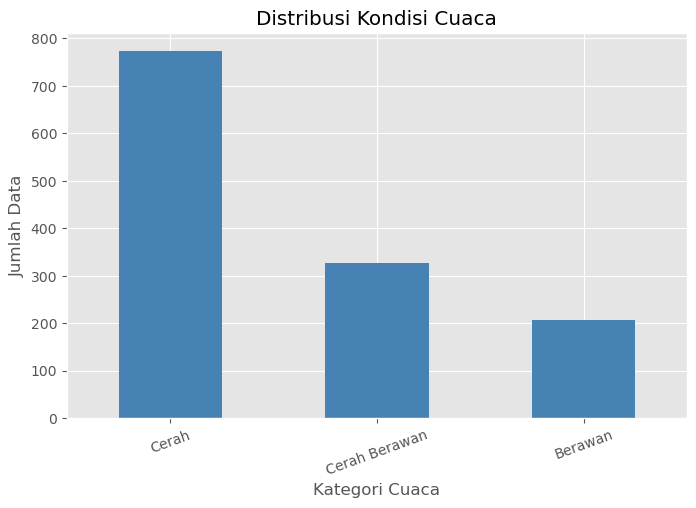

In [90]:
plt.figure(figsize=(8,5))

df["Cuaca"].value_counts().plot(
    kind="bar",
    color="steelblue"
)

plt.title("Distribusi Kondisi Cuaca")

plt.xlabel("Kategori Cuaca")

plt.ylabel("Jumlah Data")

plt.xticks(rotation=20)

plt.show()

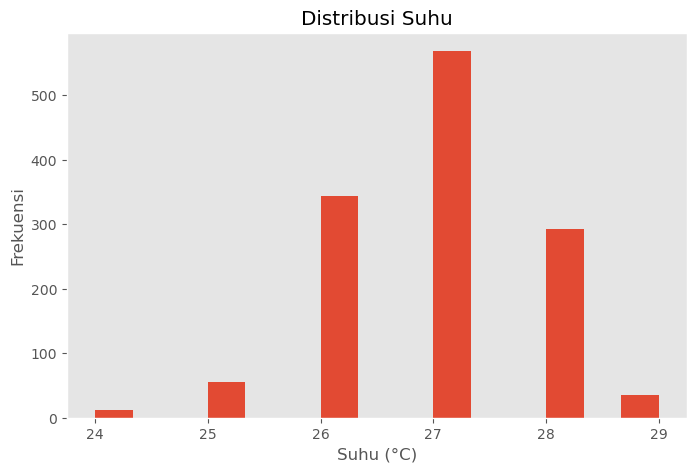

In [91]:
plt.figure(figsize=(8,5))

plt.hist(df["Suhu"], bins=15)

plt.title("Distribusi Suhu")

plt.xlabel("Suhu (°C)")

plt.ylabel("Frekuensi")

plt.grid()

plt.show()

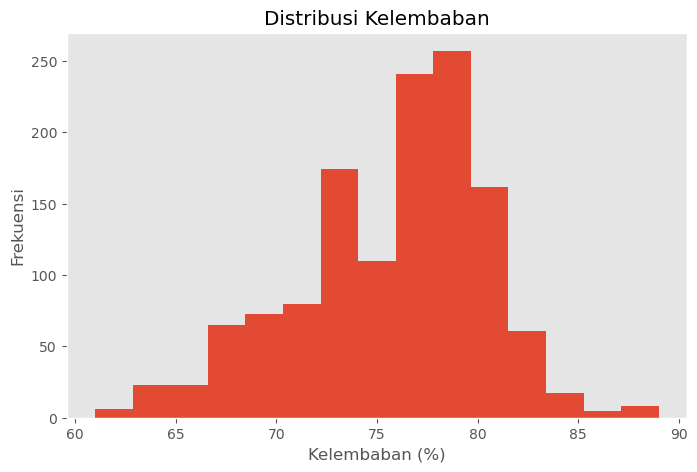

In [92]:
plt.figure(figsize=(8,5))

plt.hist(df["Kelembaban"], bins=15)

plt.title("Distribusi Kelembaban")

plt.xlabel("Kelembaban (%)")

plt.ylabel("Frekuensi")

plt.grid()

plt.show()

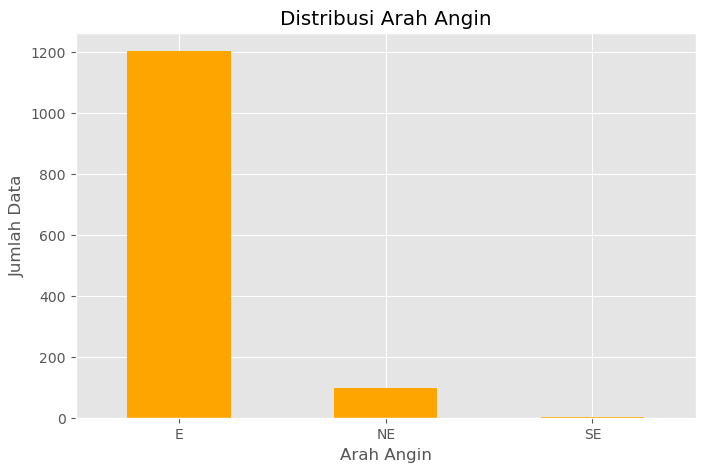

In [94]:
plt.figure(figsize=(8,5))
df["Arah_Angin"].value_counts().plot(
    kind="bar",
    color="orange"
)

plt.title("Distribusi Arah Angin")

plt.xlabel("Arah Angin")

plt.ylabel("Jumlah Data")

plt.xticks(rotation=0)

plt.show()

In [95]:
def buat_label(cuaca):

    cuaca = str(cuaca).strip().lower()

    if cuaca == "cerah":
        return "Baik"

    elif cuaca == "cerah berawan":
        return "Sedang"

    elif cuaca == "berawan":
        return "Buruk"

    elif "hujan" in cuaca:
        return "Buruk"

    else:
        return "Lainnya"

df["Label"] = df["Cuaca"].apply(buat_label)

display(df[["Cuaca","Label"]].head(15))

,Cuaca,Label
0,Cerah Berawan,Sedang
1,Cerah Berawan,Sedang
2,Cerah Berawan,Sedang
3,Berawan,Buruk
4,Cerah Berawan,Sedang
5,Berawan,Buruk
6,Cerah Berawan,Sedang
7,Berawan,Buruk
8,Berawan,Buruk
9,Cerah Berawan,Sedang


In [96]:
print("="*60)
print("JUMLAH DATA SETIAP LABEL")
print("="*60)

print(df["Label"].value_counts())

JUMLAH DATA SETIAP LABEL
Label
Baik      773
Sedang    326
Buruk     206
Name: count, dtype: int64


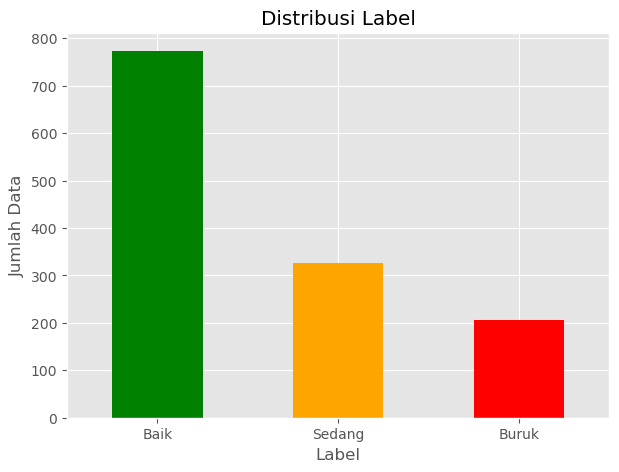

In [97]:
plt.figure(figsize=(7,5))

warna = {
    "Baik":"green",
    "Sedang":"orange",
    "Buruk":"red",
    "Lainnya":"gray"
}

df["Label"].value_counts().plot(
    kind="bar",
    color=[warna.get(i,"gray") for i in df["Label"].value_counts().index]
)

plt.title("Distribusi Label")

plt.xlabel("Label")

plt.ylabel("Jumlah Data")

plt.xticks(rotation=0)

plt.show()

In [98]:
display(df.head(10))

,Waktu,Suhu,Kelembaban,Cuaca,Angin,Visibilitas,Tutupan_Awan,Curah_Hujan,Arah_Angin,ADM4,Label
0,2026-06-30 23:00:00,25,80,Cerah Berawan,8.0,7987,90,0.0,E,73.01.04.2008,Sedang
1,2026-06-30 23:00:00,26,76,Cerah Berawan,12.8,7987,90,0.0,E,73.01.05.2005,Sedang
2,2026-06-30 23:00:00,25,79,Cerah Berawan,11.0,7987,85,0.0,E,73.01.02.1002,Sedang
3,2026-07-01 00:00:00,27,74,Berawan,9.9,7988,92,0.0,E,73.01.09.2001,Buruk
4,2026-07-01 00:00:00,26,78,Cerah Berawan,11.2,7988,90,0.0,E,73.01.03.2008,Sedang
5,2026-07-01 00:00:00,27,74,Berawan,10.6,7988,95,0.0,E,73.01.07.2007,Buruk
6,2026-07-01 00:00:00,26,77,Cerah Berawan,11.2,7988,89,0.0,E,73.01.03.2007,Sedang
7,2026-07-01 00:00:00,27,76,Berawan,9.2,7988,95,0.0,E,73.01.07.2008,Buruk
8,2026-07-01 00:00:00,26,78,Berawan,11.2,7988,90,0.0,E,73.01.03.2006,Buruk
9,2026-07-01 00:00:00,27,75,Cerah Berawan,12.6,7988,90,0.0,E,73.01.08.2001,Sedang


In [99]:
print("="*60)
print("ENCODING DATA")
print("="*60)

encoder_angin = LabelEncoder()
encoder_label = LabelEncoder()

# Encode arah angin
df["Arah_Angin"] = encoder_angin.fit_transform(df["Arah_Angin"])

# Encode label target
df["Label"] = encoder_label.fit_transform(df["Label"])

display(df.head())

ENCODING DATA


,Waktu,Suhu,Kelembaban,Cuaca,Angin,Visibilitas,Tutupan_Awan,Curah_Hujan,Arah_Angin,ADM4,Label
0,2026-06-30 23:00:00,25,80,Cerah Berawan,8.0,7987,90,0.0,0,73.01.04.2008,2
1,2026-06-30 23:00:00,26,76,Cerah Berawan,12.8,7987,90,0.0,0,73.01.05.2005,2
2,2026-06-30 23:00:00,25,79,Cerah Berawan,11.0,7987,85,0.0,0,73.01.02.1002,2
3,2026-07-01 00:00:00,27,74,Berawan,9.9,7988,92,0.0,0,73.01.09.2001,1
4,2026-07-01 00:00:00,26,78,Cerah Berawan,11.2,7988,90,0.0,0,73.01.03.2008,2


In [100]:
X = df[[
    "Suhu",
    "Kelembaban",
    "Angin",
    "Visibilitas",
    "Tutupan_Awan",
    "Curah_Hujan",
    "Arah_Angin"
]]

y = df["Label"]

print("="*60)
print("FEATURE YANG DIGUNAKAN")
print("="*60)

print(X.columns.tolist())

print()

print("Jumlah Feature :", X.shape[1])

FEATURE YANG DIGUNAKAN
['Suhu', 'Kelembaban', 'Angin', 'Visibilitas', 'Tutupan_Awan', 'Curah_Hujan', 'Arah_Angin']

Jumlah Feature : 7


In [101]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

print("="*60)
print("PEMBAGIAN DATA")
print("="*60)

print("Training :", len(X_train))

print("Testing  :", len(X_test))

PEMBAGIAN DATA
Training : 1044
Testing  : 261


In [102]:
print("="*60)
print("GAUSSIAN NAIVE BAYES")
print("="*60)

model = GaussianNB()

model.fit(X_train, y_train)

print("Model berhasil dilatih.")

GAUSSIAN NAIVE BAYES
Model berhasil dilatih.


In [103]:
y_pred = model.predict(X_test)

print("Jumlah Prediksi :", len(y_pred))

Jumlah Prediksi : 261


In [104]:
akurasi = accuracy_score(y_test, y_pred)

print("="*60)
print("HASIL UJI MODEL")
print("="*60)

print("Akurasi Model : %.2f%%"%(akurasi*100))

HASIL UJI MODEL
Akurasi Model : 91.57%


In [105]:
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(

    classification_report(

        y_test,

        y_pred,

        target_names=encoder_label.classes_

    )

)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Baik       0.99      0.93      0.96       155
       Buruk       0.88      0.88      0.88        41
      Sedang       0.79      0.91      0.84        65

    accuracy                           0.92       261
   macro avg       0.89      0.90      0.89       261
weighted avg       0.92      0.92      0.92       261



In [106]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[144   0  11]
 [  0  36   5]
 [  1   5  59]]


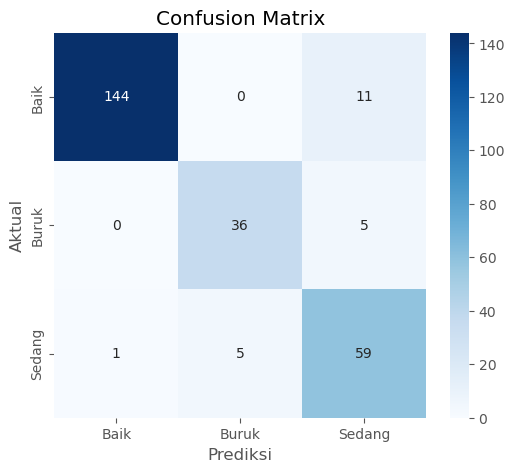

In [107]:
plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=encoder_label.classes_,

    yticklabels=encoder_label.classes_

)

plt.xlabel("Prediksi")

plt.ylabel("Aktual")

plt.title("Confusion Matrix")

plt.show()

In [108]:
hasil_prediksi = pd.DataFrame({

    "Aktual" : encoder_label.inverse_transform(y_test),

    "Prediksi" : encoder_label.inverse_transform(y_pred)

})

display(hasil_prediksi.head(20))

,Aktual,Prediksi
0,Baik,Baik
1,Sedang,Sedang
2,Buruk,Buruk
3,Buruk,Sedang
4,Buruk,Buruk
5,Buruk,Buruk
6,Sedang,Sedang
7,Sedang,Sedang
8,Baik,Baik
9,Baik,Baik


In [109]:
contoh = pd.DataFrame({

    "Suhu":[30],

    "Kelembaban":[75],

    "Angin":[10],

    "Visibilitas":[8000],

    "Tutupan_Awan":[40],

    "Curah_Hujan":[0],

    "Arah_Angin":["E"]

})

contoh["Arah_Angin"] = encoder_angin.transform(contoh["Arah_Angin"])

hasil = model.predict(contoh)

print("="*60)
print("HASIL PREDIKSI DATA BARU")
print("="*60)

print(

    "Prediksi Cuaca :",

    encoder_label.inverse_transform(hasil)[0]

)

HASIL PREDIKSI DATA BARU
Prediksi Cuaca : Baik


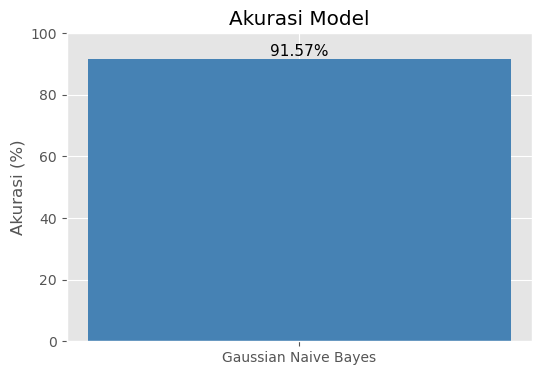

In [110]:
plt.figure(figsize=(6,4))

plt.bar(
    ["Gaussian Naive Bayes"],
    [akurasi*100],
    color="steelblue"
)

plt.ylim(0,100)

plt.ylabel("Akurasi (%)")

plt.title("Akurasi Model")

for i, v in enumerate([akurasi*100]):
    plt.text(i, v+1, f"{v:.2f}%", ha='center', fontsize=11)

plt.show()

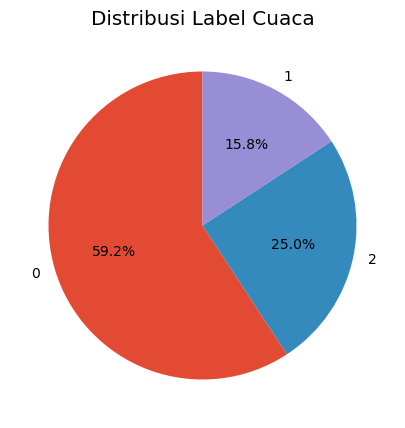

In [111]:
plt.figure(figsize=(7,5))

df["Label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")

plt.title("Distribusi Label Cuaca")

plt.show()

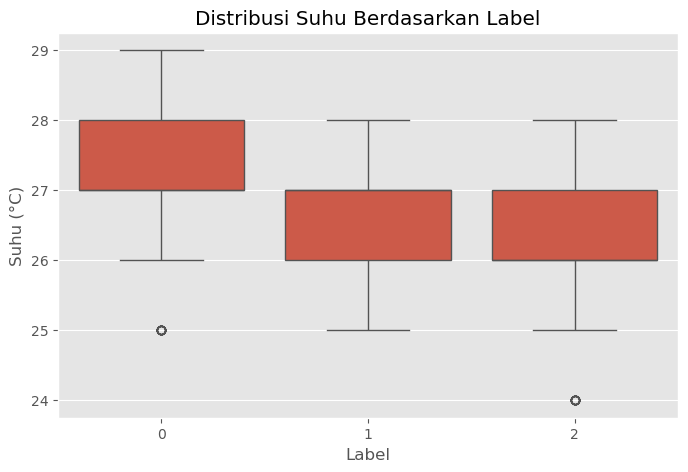

In [112]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Label"],
    y=df["Suhu"]
)

plt.title("Distribusi Suhu Berdasarkan Label")

plt.xlabel("Label")

plt.ylabel("Suhu (°C)")

plt.show()

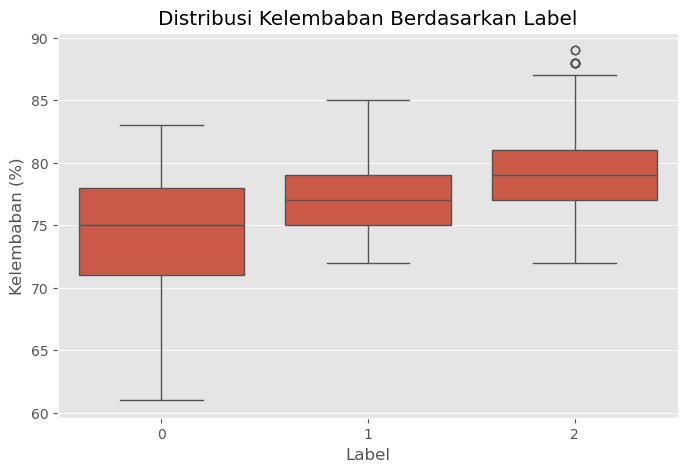

In [113]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Label"],
    y=df["Kelembaban"]
)

plt.title("Distribusi Kelembaban Berdasarkan Label")

plt.xlabel("Label")

plt.ylabel("Kelembaban (%)")

plt.show()

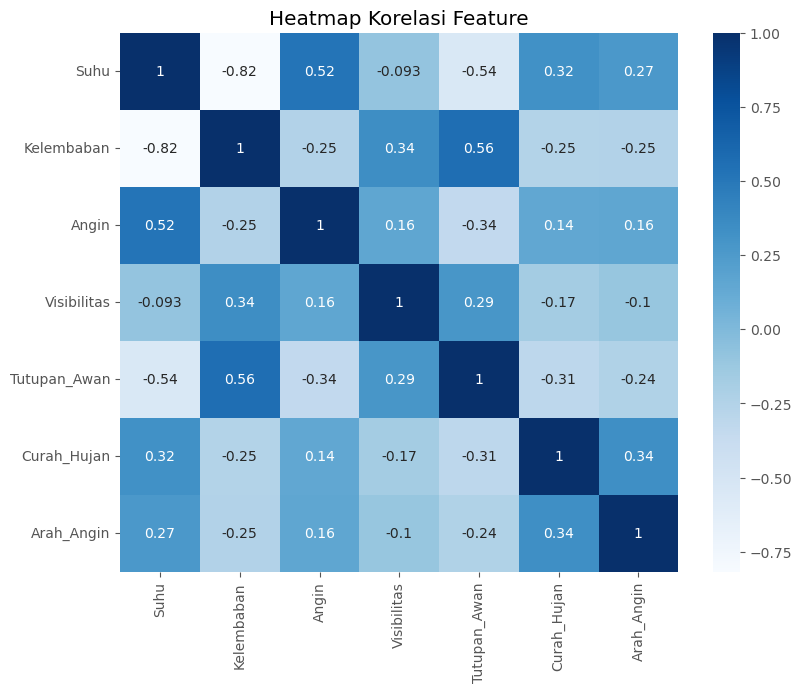

In [114]:
plt.figure(figsize=(9,7))

sns.heatmap(

    X.corr(),

    annot=True,

    cmap="Blues"

)

plt.title("Heatmap Korelasi Feature")

plt.show()

In [115]:
contoh = pd.DataFrame({

    "Suhu":[30],

    "Kelembaban":[80],

    "Angin":[10],

    "Visibilitas":[8000],

    "Tutupan_Awan":[30],

    "Curah_Hujan":[0],

    "Arah_Angin":["E"]

})

contoh["Arah_Angin"] = encoder_angin.transform(contoh["Arah_Angin"])

prediksi = model.predict(contoh)

hasil = encoder_label.inverse_transform(prediksi)

print("="*60)

print("HASIL PREDIKSI DATA BARU")

print("="*60)

print("Prediksi Kondisi Cuaca :", hasil[0])

HASIL PREDIKSI DATA BARU
Prediksi Kondisi Cuaca : Baik


In [116]:
print("="*60)
print("RINGKASAN MODEL")
print("="*60)

print(f"Jumlah Dataset        : {len(df)}")

print(f"Jumlah Data Training  : {len(X_train)}")

print(f"Jumlah Data Testing   : {len(X_test)}")

print(f"Akurasi Model         : {akurasi*100:.2f}%")

print(f"Jumlah Feature        : {X.shape[1]}")

print(f"Jumlah Label          : {len(encoder_label.classes_)}")

RINGKASAN MODEL
Jumlah Dataset        : 1305
Jumlah Data Training  : 1044
Jumlah Data Testing   : 261
Akurasi Model         : 91.57%
Jumlah Feature        : 7
Jumlah Label          : 3
